In [2]:
import pandas as pd
import numpy as np

In [12]:
df=pd.read_csv('../data/amazon_sale_report.csv')

C:\Users\mrai4\AppData\Local\Temp\ipykernel_17828\2197202442.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('../data/amazon_sale_report.csv')


In [13]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [18]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [25]:
print(df['Status'].unique())

print(df['Category'].unique())

print(df['Fulfilment'].unique())

print(df['Courier Status'].unique())

print(df['Sales Channel '].unique())

print(df['B2B'].unique())

print(df['ship-country'].unique())

<ArrowStringArray>
[                    'Cancelled',  'Shipped - Delivered to Buyer',
                       'Shipped',  'Shipped - Returned to Seller',
   'Shipped - Rejected by Buyer',     'Shipped - Lost in Transit',
    'Shipped - Out for Delivery', 'Shipped - Returning to Seller',
           'Shipped - Picked Up',                       'Pending',
 'Pending - Waiting for Pick Up',             'Shipped - Damaged',
                      'Shipping']
Length: 13, dtype: str
<ArrowStringArray>
[          'Set',         'kurta', 'Western Dress',           'Top',
  'Ethnic Dress',        'Bottom',         'Saree',        'Blouse',
       'Dupatta']
Length: 9, dtype: str
<ArrowStringArray>
['Merchant', 'Amazon']
Length: 2, dtype: str
<ArrowStringArray>
[nan, 'Shipped', 'Cancelled', 'Unshipped']
Length: 4, dtype: str
<ArrowStringArray>
['Amazon.in', 'Non-Amazon']
Length: 2, dtype: str
[False  True]
<ArrowStringArray>
['IN', nan]
Length: 2, dtype: str


In [26]:
null_percent = (
    df.isnull().sum() / len(df)
) * 100

null_percent.sort_values(
    ascending=False
)

fulfilled-by          69.546811
promotion-ids         38.110487
Unnamed: 22           38.030626
currency               6.043807
Amount                 6.043807
Courier Status         5.328164
ship-country           0.025586
ship-city              0.025586
ship-state             0.025586
ship-postal-code       0.025586
Sales Channel          0.000000
Fulfilment             0.000000
Status                 0.000000
Date                   0.000000
Order ID               0.000000
index                  0.000000
Style                  0.000000
ship-service-level     0.000000
Qty                    0.000000
ASIN                   0.000000
SKU                    0.000000
Category               0.000000
Size                   0.000000
B2B                    0.000000
dtype: float64

In [27]:
drop_cols = [
    'index',
    'Unnamed: 22',
    'promotion-ids',
    'ASIN',
    'SKU',
    'ship-postal-code'
]

df.drop(
    columns=drop_cols,
    inplace=True
)

In [28]:
df['Courier Status'] = (
    df['Courier Status']
    .fillna('Unknown')
)

In [29]:
df['currency'] = (
    df['currency']
    .fillna('INR')
)

In [30]:
df['Amount'] = (
    df['Amount']
    .fillna(
        df['Amount'].median()
    )
)

In [31]:
df['ship-city'] = (
    df['ship-city']
    .fillna('Unknown')
)

df['ship-state'] = (
    df['ship-state']
    .fillna('Unknown')
)

In [32]:
df['fulfilled-by'] = (
    df['fulfilled-by']
    .fillna('Merchant')
)

In [33]:
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

C:\Users\mrai4\AppData\Local\Temp\ipykernel_17828\2904991754.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(


In [40]:
df['Year'] = (
    df['Date'].dt.year
)

df['Month'] = (
    df['Date']
    .dt.month_name()
)

df['Month_num'] = (
    df['Date']
    .dt.month
)

df['Day'] = (
    df['Date']
    .dt.day_name()
)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128975 non-null  str           
 1   Date                128975 non-null  datetime64[us]
 2   Status              128975 non-null  str           
 3   Fulfilment          128975 non-null  str           
 4   Sales Channel       128975 non-null  str           
 5   ship-service-level  128975 non-null  str           
 6   Style               128975 non-null  str           
 7   Category            128975 non-null  str           
 8   Size                128975 non-null  str           
 9   Courier Status      128975 non-null  str           
 10  Qty                 128975 non-null  int64         
 11  currency            128975 non-null  str           
 12  Amount              128975 non-null  float64       
 13  ship-city           128975 non-null  str

In [44]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,Category,Size,Courier Status,...,Amount,ship-city,ship-state,ship-country,B2B,fulfilled-by,Year,Month,Month_num,Day
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,Set,S,Unknown,...,647.62,MUMBAI,MAHARASHTRA,IN,False,Easy Ship,2022,April,4,Saturday
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,kurta,3XL,Shipped,...,406.00,BENGALURU,KARNATAKA,IN,False,Easy Ship,2022,April,4,Saturday
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,kurta,XL,Shipped,...,329.00,NAVI MUMBAI,MAHARASHTRA,IN,True,Merchant,2022,April,4,Saturday
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,Western Dress,L,Unknown,...,753.33,PUDUCHERRY,PUDUCHERRY,IN,False,Easy Ship,2022,April,4,Saturday
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,Top,3XL,Shipped,...,574.00,CHENNAI,TAMIL NADU,IN,False,Merchant,2022,April,4,Saturday


In [47]:
df.to_csv(
    "../data/cleaned_amazon_sales.csv",
    index=False
)

## EDA

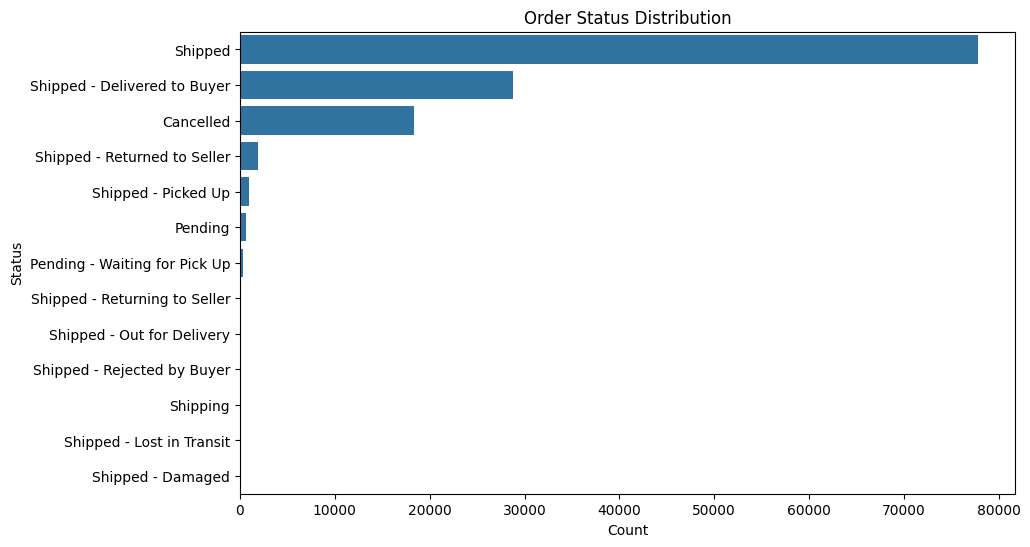

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    y='Status',
    data=df,
    order=df['Status'].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Count")
plt.ylabel("Status")

plt.show()

Most orders were successfully shipped and delivered, indicating strong operational efficiency. However, cancelled and returned orders still represent a noticeable share, suggesting opportunities to improve customer satisfaction and logistics.

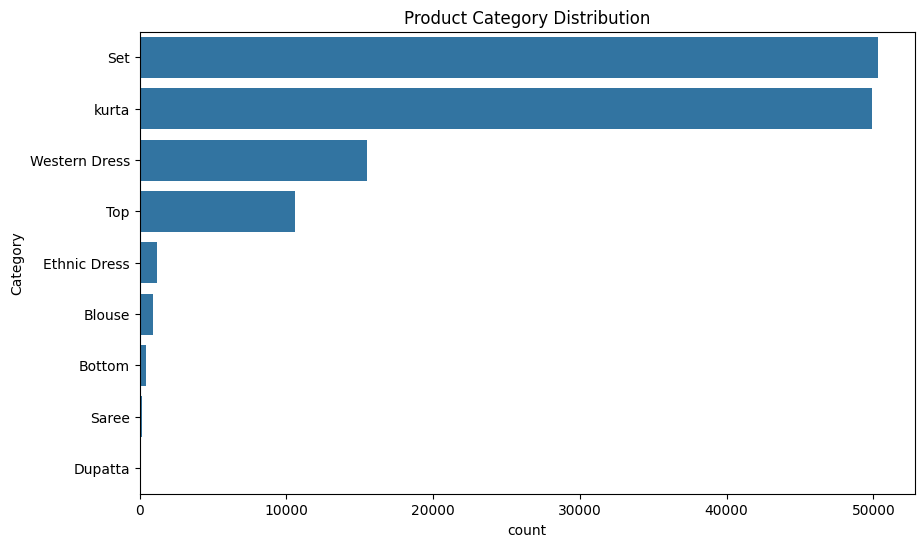

In [50]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index
)

plt.title("Product Category Distribution")
plt.show()

The dataset is dominated by a few major product categories such as Set, Kurta, western Dress and Top, indicating stronger customer preference and sales concentration in specific apparel segments.

In [52]:
category_sales = (
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Set              41165534.03
kurta            23211346.70
Western Dress    11697652.69
Top               5624277.30
Ethnic Dress       831147.66
Blouse             485633.18
Bottom             162767.98
Saree              129378.76
Dupatta               915.00
Name: Amount, dtype: float64

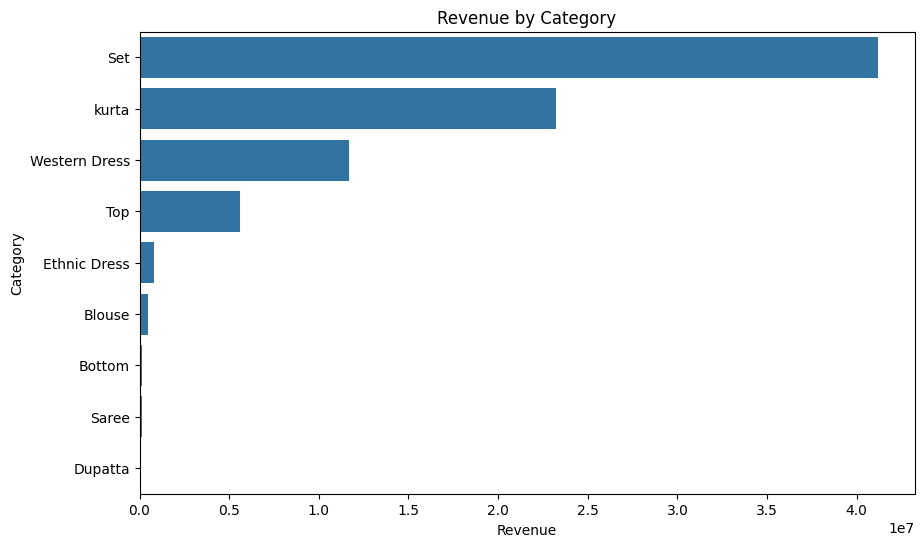

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Revenue by Category")
plt.xlabel("Revenue")

plt.show()

Certain product categories contribute disproportionately higher revenue, suggesting they are key revenue drivers and should receive greater inventory and marketing focus.

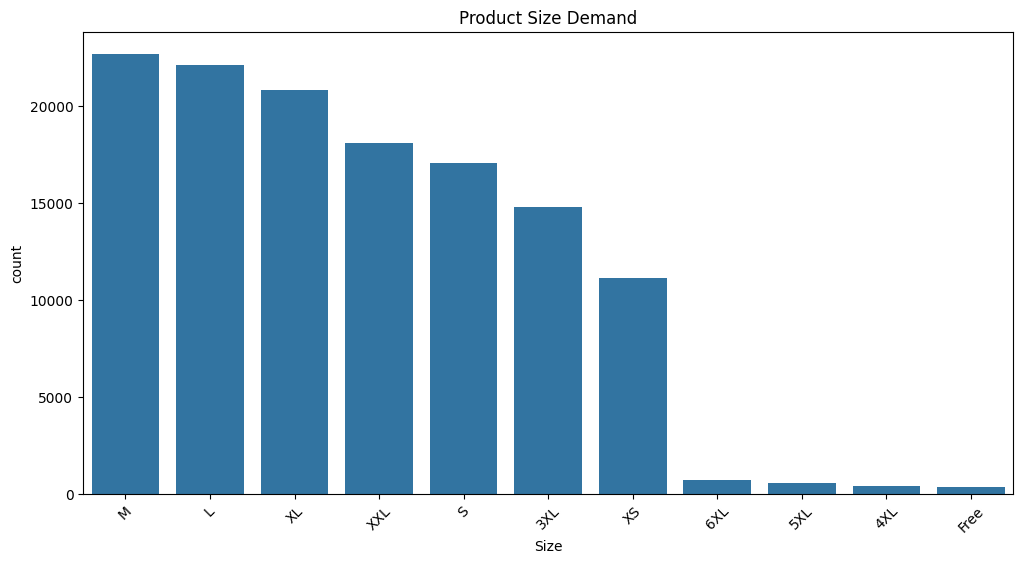

In [54]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Size',
    data=df,
    order=df['Size'].value_counts().index
)

plt.title("Product Size Demand")

plt.xticks(rotation=45)

plt.show()

Mid-range sizes appear to have the highest demand, reflecting customer purchasing preferences. Low-demand sizes may require optimized inventory management to reduce overstock.

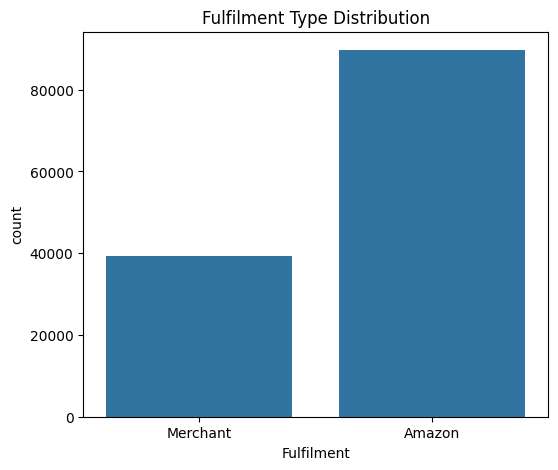

In [55]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Fulfilment',
    data=df
)

plt.title("Fulfilment Type Distribution")

plt.show()

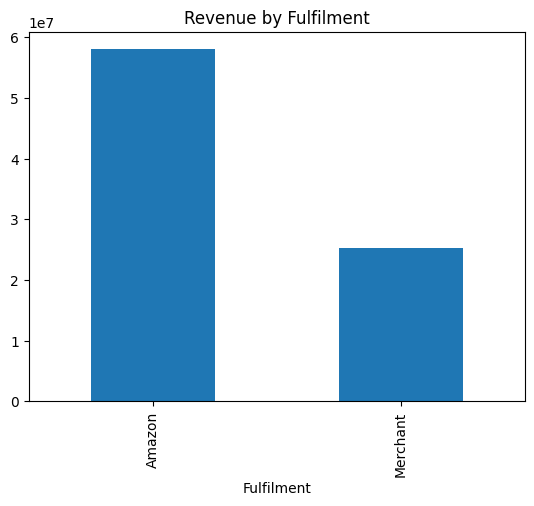

In [56]:
fulfillment_sales = (
    df.groupby('Fulfilment')['Amount']
    .sum()
)

fulfillment_sales.plot(
    kind='bar'
)

plt.title(
    "Revenue by Fulfilment"
)

plt.show()

Amazon fulfilment handles a significant share of orders, showing reliance on platform logistics for efficient delivery and customer trust.It also generates higher revenue than the other, indicating better sales performance and possibly stronger customer confidence in delivery quality.

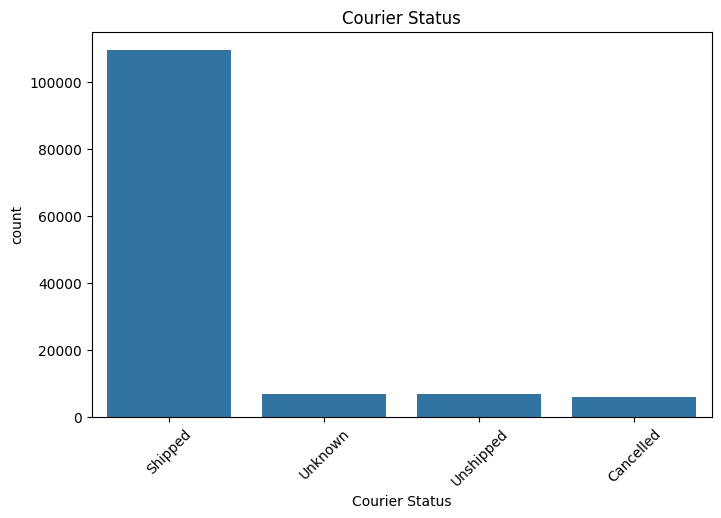

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Courier Status',
    data=df,
    order=df['Courier Status']
    .value_counts()
    .index
)

plt.title("Courier Status")

plt.xticks(rotation=45)

plt.show()

Most shipments are successfully delivered, reflecting effective logistics operations. A small percentage of unshipped or cancelled orders highlights areas for supply chain improvement.

In [58]:
monthly_sales = (
    df.groupby('Month_num')['Amount']
    .sum()
)

monthly_sales

Month_num
1      3066601.33
2      3180541.41
3      3254665.01
4     21815365.00
5     18802696.32
6     16149339.88
7      2946870.37
8      3062922.76
9      2895270.46
10     2741032.85
11     2700161.13
12     2693186.78
Name: Amount, dtype: float64

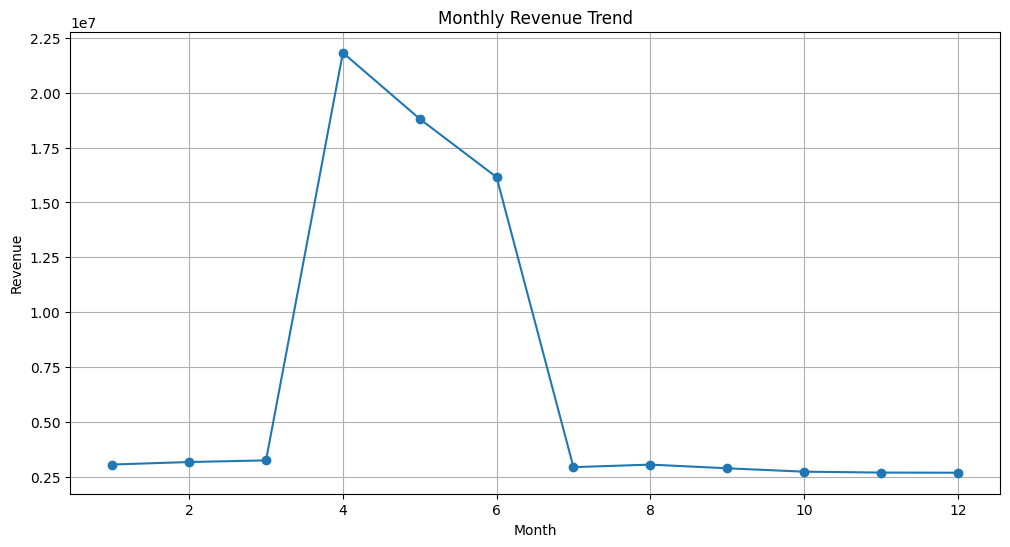

In [59]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o'
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Revenue fluctuates across months, with peak periods (4-6 months) indicating higher customer demand, possibly influenced by seasonal shopping trends or promotional campaigns.

In [60]:
state_sales = (
    df.groupby('ship-state')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

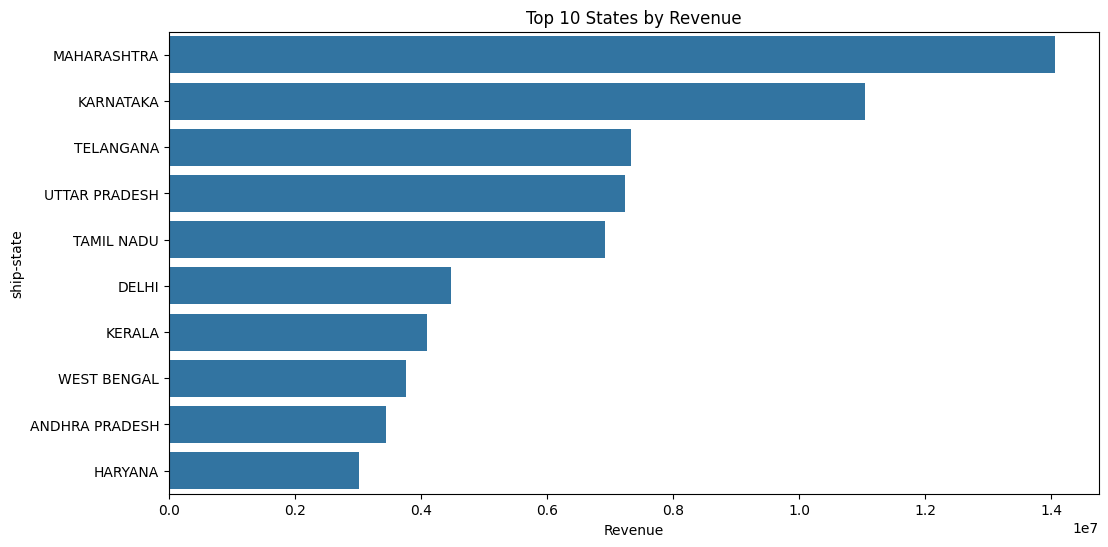

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index
)

plt.title(
    "Top 10 States by Revenue"
)

plt.xlabel("Revenue")

plt.show()

Revenue is concentrated in a few states, showing stronger market penetration in these regions. These areas may be prioritized for targeted promotions and customer retention strategies.

In [62]:
city_sales = (
    df.groupby('ship-city')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

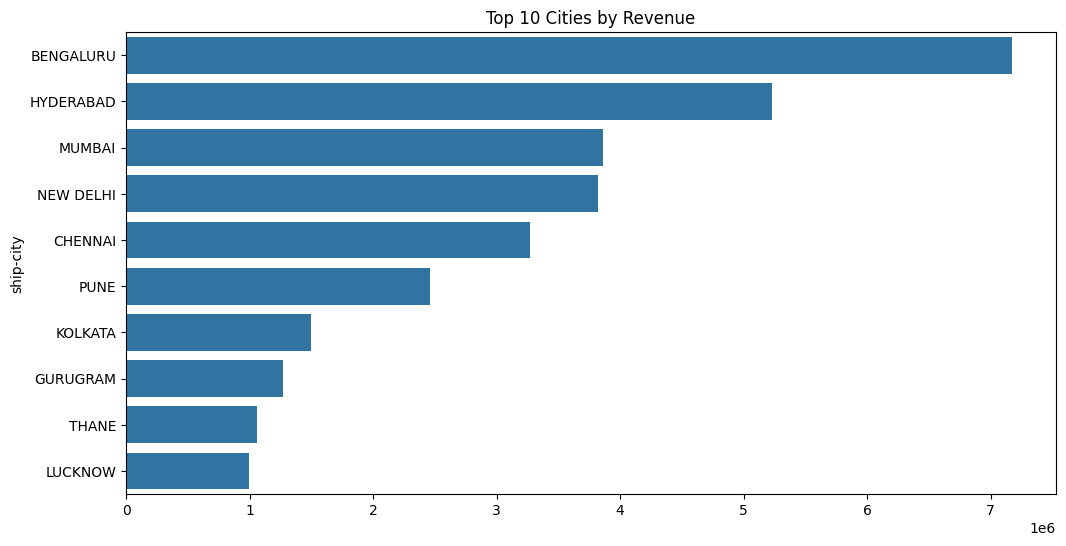

In [63]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title(
    "Top 10 Cities by Revenue"
)

plt.show()

Major cities like BENGALURU, MUMBAI, NEW DELHI, CHENNAI contribute the highest revenue, suggesting stronger urban demand and purchasing activity compared to smaller cities.

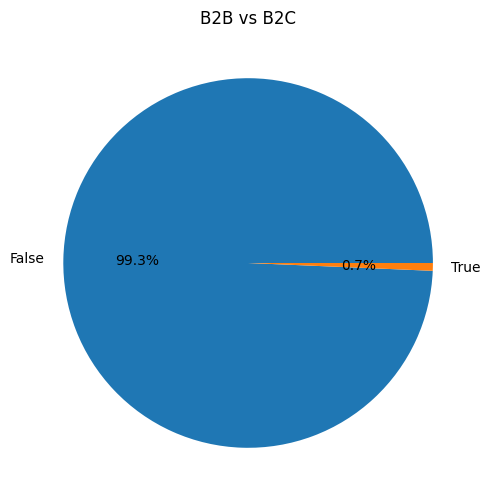

In [73]:
plt.figure(figsize=(6,6))

df['B2B'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("B2B vs B2C")

plt.ylabel("")

plt.show()

The business is primarily driven by B2C customers, indicating stronger dependence on individual consumer demand rather than bulk or enterprise purchases.

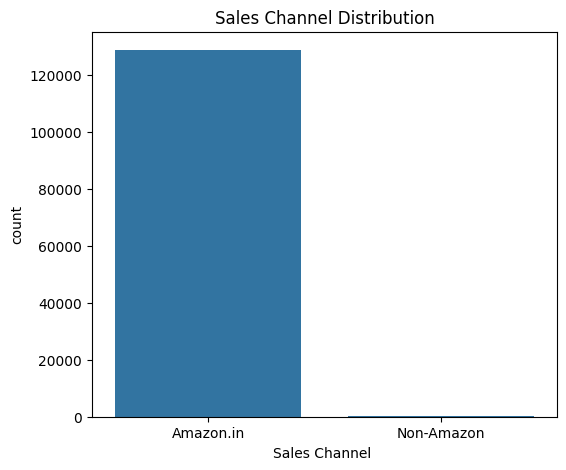

In [65]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Sales Channel ',
    data=df
)

plt.title(
    "Sales Channel Distribution"
)

plt.show()

Amazon sales channel dominates transactions, suggesting it is the primary customer acquisition platform and business dependency is concentrated ther

In [66]:
top_styles = (
    df.groupby('Style')['Qty']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

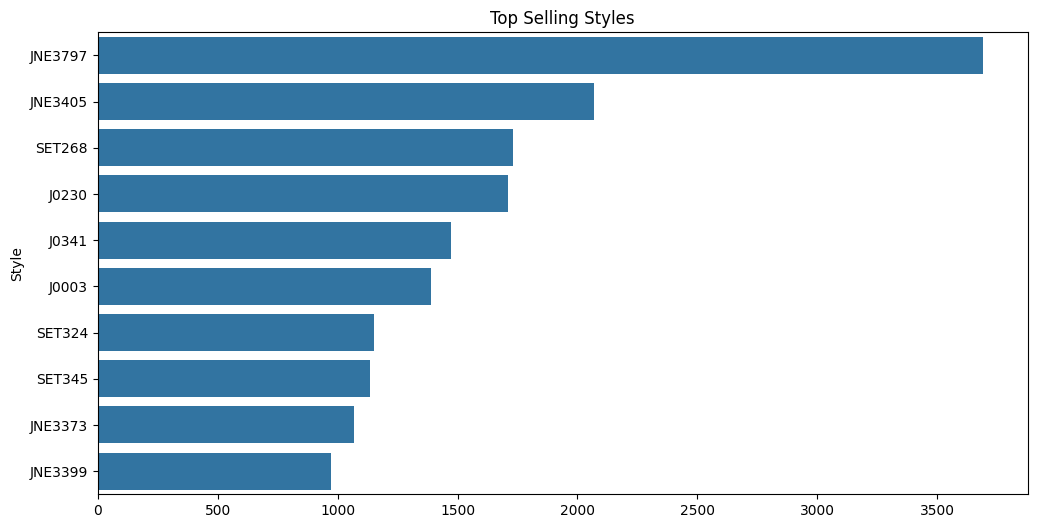

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_styles.values,
    y=top_styles.index
)

plt.title(
    "Top Selling Styles"
)

plt.show()

A limited number of styles contribute most sales volume, indicating customer preference for specific fashion trends and product designs.

In [68]:
corr = df[
    ['Qty', 'Amount']
].corr()

corr

,Qty,Amount
Qty,1.000000,0.071525
Amount,0.071525,1.000000


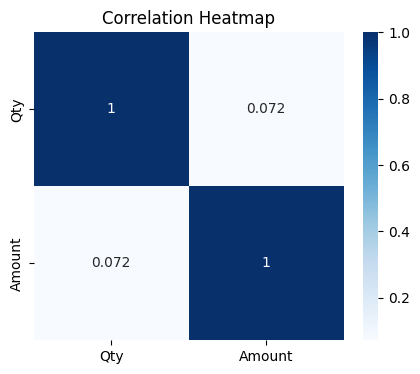

In [69]:
plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

The relationship between quantity sold and revenue appears weak, indicating how much purchase volume influences overall sales value.

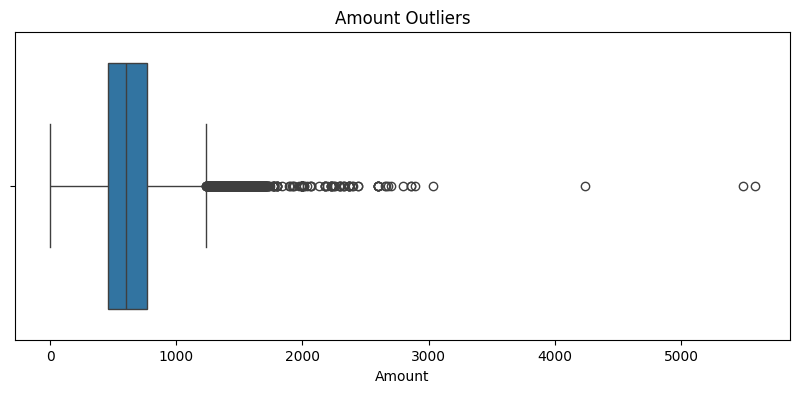

In [70]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Amount']
)

plt.title(
    "Amount Outliers"
)

plt.show()

Revenue contains several high-value outliers, indicating the presence of premium or bulk purchases that significantly influence overall sales performance.

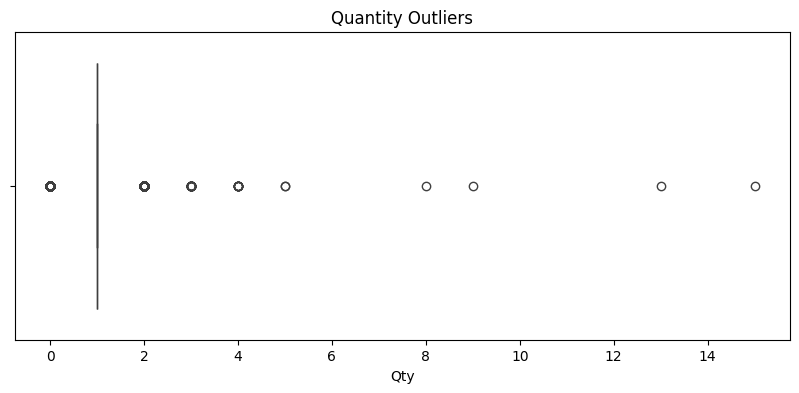

In [71]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Qty']
)

plt.title(
    "Quantity Outliers"
)

plt.show()

Most orders contain a low quantity of items, with the majority clustered around 1 unit per order. However, a small number of orders contain unusually high quantities (up to ~15 units), indicating the presence of bulk or high-volume purchases.